# Classical Statistics: The Art of Line Drawing

## 1. Introduction: The Foundations of Inference

Before the era of massive GPU clusters and billion-parameter models, there was **Classical Statistics**. While modern Machine Learning often treats the model as a "Black Box" optimization problem (focusing purely on predictive accuracy), Classical Statistics treats data modeling as a **scientific inquiry**.

In this paradigm, we do not simply ask *"What is the prediction?"*. We ask tougher questions:
- **"How** exactly does variable $X$ impact $Y$?" (Interpretability)
- **"How confident** are we that this relationship is real and not just noise?" (Statistical Significance)
- **"Does the data** actually obey the physical laws we are modeling?" (Diagnostics)

### 1.1 The Philosophy: Inference vs. Prediction
There is a fundamental philosophical divide in data science:

1.  **The Algorithmic View (Machine Learning):** Nature is complex and unknown. We aim to find a function $f(x)$ that creates the best mapping to $y$ on unseen data. We care less about the form of $f(x)$ and more about the test error.
2.  **The Data Modeling View (Classical Statistics):** We assume the data comes from a specific stochastic process (e.g., a linear combination plus Gaussian noise). Our goal is to estimate the parameters of that process. If the assumption is wrong, the model is invalid, regardless of accuracy.

### 1.2 The Structural Assumption
In Classical Regression, we posit that reality follows a rigid, additive structure:

$$ y = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n + \epsilon $$

Where:
- $\beta$ are the **parameters** (the signal we want to recover).
- $\epsilon$ is the **irreducible error** (the noise of the universe).

Our entire goal is to separate the signal from the noise mathematically.

### 1.3 The Rules of the Game: The "LINE" Assumptions
Unlike a Random Forest, you cannot just throw data at OLS (Ordinary Least Squares) and hope for the best. Valid statistical inference requires adherence to strict assumptions. If these break, your P-values and Confidence Intervals become meaningless.

- **L - Linearity:** The relationship between $X$ and the mean of $Y$ is linear.
- **I - Independence:** Observations are independent of each other (no autocorrelation).
- **N - Normality:** The error terms $\epsilon$ are normally distributed.
- **E - Equal Variance (Homoscedasticity):** The spread of errors is constant across all values of $X$.

### 1.4 The Roadmap
In this notebook, we will deconstruct the four pillars of Classical Regression, moving from the simplest assumptions to more complex reality-handling:

1.  **Ordinary Least Squares (OLS):** The "Hello World" of regression. Minimizing the sum of squared errors.
2.  **Polynomial Regression:** Bending the line. How to model curvature ($x^2, x^3$) while keeping the math linear.
3.  **Generalized Linear Models (GLMs):** Breaking the Normality assumption. What if our data is a count (Poisson)? Or a Yes/No probablity (Logistic)? Or skewed positive values (Gamma)?
4.  **Partial Least Squares (PLS):** The curse of dimensionality. How to regress when you have more features than samples.

---
*We follow the **ATLAS** protocol: First we understand the **Intuition**, then we build it from **Scratch** using only Linear Algebra, and finally we apply the **Pro** tools used in industry.*

## 2. Ordinary Least Squares (OLS): The Baseline

### 2.1 The Intuition
Imagine you are trying to predict the fuel efficiency (**MPG**) of a car based on its engine power (**Horsepower**). 

The simplest mental model is: *"The more powerful the engine, the more gas it guzzles, at a constant rate."*

This is **Linear Regression**. We strictly assume that for every unit increase in Horsepower, MPG drops by a fixed amount $\beta$. We want to find the single straight line that passes through the data cloud such that the total squared distance between the points and the line is minimized.

Why specificially "Least Squares"? Because squaring the errors penalizes large mistakes much more than small ones, forcing the model to try and satisfy the outliers.

### 2.2 The Dataset: Auto MPG
We will use the famous **Auto MPG** dataset. 
- **Input ($X$):** Horsepower
- **Output ($y$):** MPG (Miles Per Gallon)

This dataset is excellent because, as we will see, physics (aerodynamic drag, engine friction) is rarely linear.

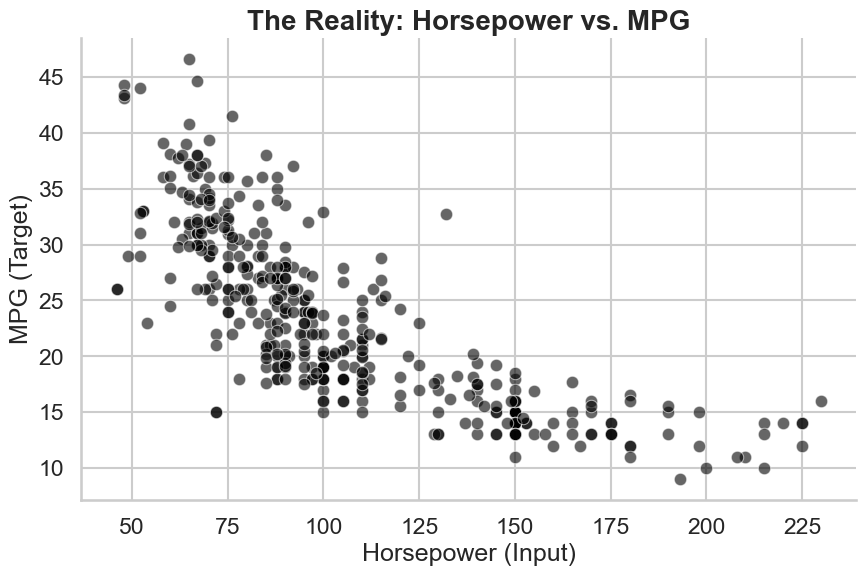

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set premium style
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'

# 1. Load Data
# 'mpg' is a built-in Seaborn dataset
df = sns.load_dataset("mpg").dropna()

# Select our variables
X_raw = df[['horsepower']].values
y_raw = df['mpg'].values

# Plot the raw data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['horsepower'], y=df['mpg'], color='black', alpha=0.6, s=80, edgecolor='w')
plt.title("The Reality: Horsepower vs. MPG", fontsize=20, weight='bold')
plt.xlabel("Horsepower (Input)")
plt.ylabel("MPG (Target)")
sns.despine()
plt.show()

### 2.3 The Logic (From Scratch)

How do we find the perfect $\beta$? We don't need Gradient Descent for this. There is a precise, "closed-form" linear algebra solution called the **Normal Equation**:

$$ \hat{\beta} = (X^T X)^{-1} X^T y $$

**What is happening here?**
1.  **$X^T y$**: We compute the correlation (dot product) between our features and the target. This tells us the "direction" of the relationship.
2.  **$X^T X$**: We compute the variance/covariance of the features. This accounts for the "scale" and how features overlap.
3.  **$(X^T X)^{-1}$**: We divide the correlation by the variance (like normalizing).

*Note: We must add a column of 1s to our $X$ matrix to represent the "Intercept" ($\beta_0$), otherwise our line is forced to pass through the origin (0,0).*

In [2]:
class ScratchOLS:
    def __init__(self):
        self.coeffs = None

    def fit(self, X, y):
        # 1. Add Bias Term (Intercept)
        # Creates a matrix [1, x_1], [1, x_2] ...
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])

        # 2. The Normal Equation: (X^T * X)^(-1) * X^T * y
        # np.linalg.inv computes the multiplicative inverse of a matrix
        self.coeffs = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
    def predict(self, X):
        # 1. Add Bias Term
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        
        # 2. Dot Product: y = X * beta
        return X_b @ self.coeffs

# --- Execution ---
model_scratch = ScratchOLS()
model_scratch.fit(X_raw, y_raw)
y_pred_scratch = model_scratch.predict(X_raw)

print(f"Scratch Model Weights:")
print(f"Intercept: {model_scratch.coeffs[0]:.4f}")
print(f"Slope:     {model_scratch.coeffs[1]:.4f}")

Scratch Model Weights:
Intercept: 39.9359
Slope:     -0.1578


### 2.4 The Professional Standard & Visualization

Now we verify our scratch code against the industry standard `scikit-learn`. The results should be mathematically identical. We will then visualize the result to critique the model.

Scikit-Learn Weights:
Intercept: 39.9359
Slope:     -0.1578
------------------------------
R-Squared (Explained Variance): 0.606


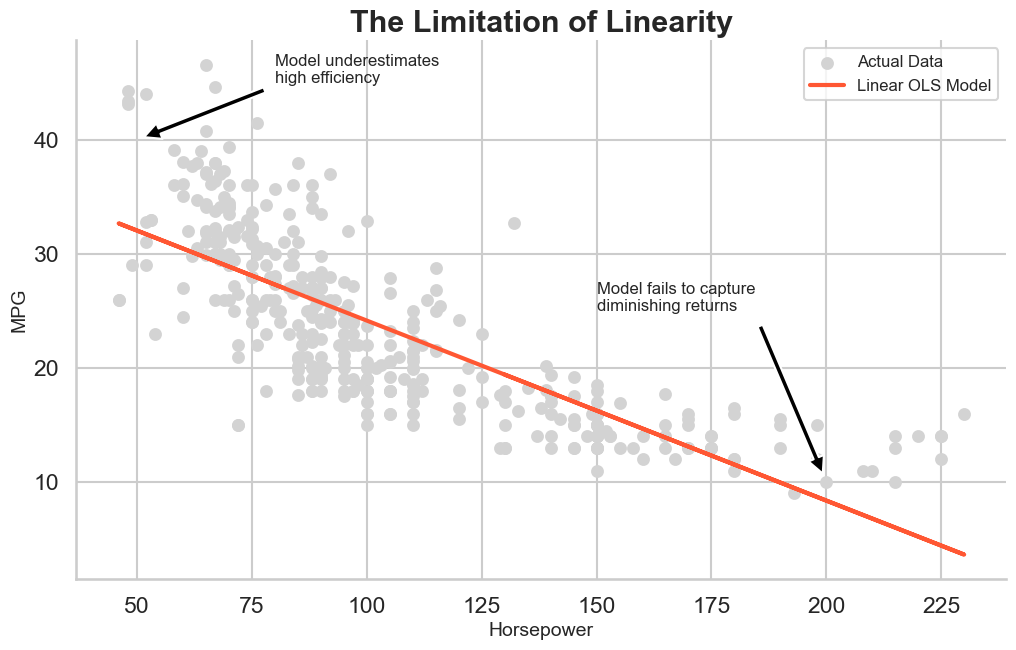

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Scikit-Learn Implementation
model_sk = LinearRegression()
model_sk.fit(X_raw, y_raw)
y_pred_sk = model_sk.predict(X_raw)

# 2. Validation
print("Scikit-Learn Weights:")
print(f"Intercept: {model_sk.intercept_:.4f}")
print(f"Slope:     {model_sk.coef_[0]:.4f}")
print("-" * 30)
print(f"R-Squared (Explained Variance): {r2_score(y_raw, y_pred_sk):.3f}")

# 3. Visualization
plt.figure(figsize=(12, 7))

# Original Data
plt.scatter(X_raw, y_raw, color='lightgray', s=60, label='Actual Data')

# The Regression Line
plt.plot(X_raw, y_pred_sk, color='#FF5733', linewidth=3, label='Linear OLS Model')

# Annotations to Highlight the Flaw
plt.title("The Limitation of Linearity", fontsize=22, weight='bold')
plt.xlabel("Horsepower", fontsize=14)
plt.ylabel("MPG", fontsize=14)

# Highlight the graphical gap (Underfitting)
plt.annotate('Model underestimates\nhigh efficiency',
             xy=(50, 40), xytext=(80, 45),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.annotate('Model fails to capture\ndiminishing returns',
             xy=(200, 10), xytext=(150, 25),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.legend(fontsize=12)
sns.despine()
plt.show()

### 2.5 Critique & Interpretation

**1. The Coefficients:**
-   **Intercept ($\beta_0 \approx 39.94$):** This suggests that a theoretical car with 0 Horsepower would get ~40 MPG. While physically impossible (a car needs an engine!), it serves as the anchor point for our line.
-   **Slope ($\beta_1 \approx -0.16$):** This is the crucial insight. For every **1 unit increase in Horsepower**, fuel efficiency **drops by 0.16 MPG**. The negative sign confirms the physics: more power = less efficiency.

**2. The Fit ($R^2 \approx 0.606$):**
-   An $R^2$ of 0.61 means our simple line explains roughly **61% of the variation** in MPG. It's "okay", but nearly 40% of the behavior is left unexplained (noise or missing pattern).

**3. The Visual Flaw:**
-   **Systematic Bias:** Look at the plot. The data forms a clear curve (like a banana). Our red line cuts straight through it. 
-   **The Consequence:** At low HP (50-75), we massively **underestimate** efficiency. At high HP (200+), we imply MPG could eventually go negative! 

The Linear assumption ($y = mx + b$) is too rigid. We need to let the line bend.

## 3. Polynomial Regression: Bending the Line

### 3.1 The Intuition
How do we model a curve when linear algebra only solves for lines?

**The Trick:** We can keep the model **linear in its parameters** ($\beta$) while making it **non-linear in its features** ($X$).

Instead of:
$$ y = \beta_0 + \beta_1 x $$

We use:
$$ y = \beta_0 + \beta_1 x + \beta_2 x^2 $$

To the algorithm, $x^2$ is just another column of numbers. It doesn't know it came from squaring the first column. It treats it as a new feature $x_2$. By giving the model "squared horsepower" as an input, it can learn a curved relationship (a parabola).

### 3.2 The Logic (From Scratch)
We don't need a new algorithm. We just need to transform our data ($X$) before feeding it into the exact same OLS solver we built above.

In [4]:
# 1. Feature Engineering: Create Polynomial Features (Degree 2)
# We add a new column: x^2
X_poly_raw = np.hstack([X_raw, X_raw**2])

# 2. Train the Scratch Model on Enhanced Data
model_poly = ScratchOLS()
model_poly.fit(X_poly_raw, y_raw)

print("Polynomial Model Weights (Scratch):")
print(f"Intercept: {model_poly.coeffs[0]:.4f}")
print(f"Beta (x): {model_poly.coeffs[1]:.4f}")
print(f"Beta (x^2): {model_poly.coeffs[2]:.4f}")

Polynomial Model Weights (Scratch):
Intercept: 56.9001
Beta (x): -0.4662
Beta (x^2): 0.0012


### 3.3 The Professional Standard & Visualization
In `scikit-learn`, we use `PolynomialFeatures` to automate this transformation. Let's visualize the difference between the Linear (Degree 1) and Polynomial (Degree 2) models.

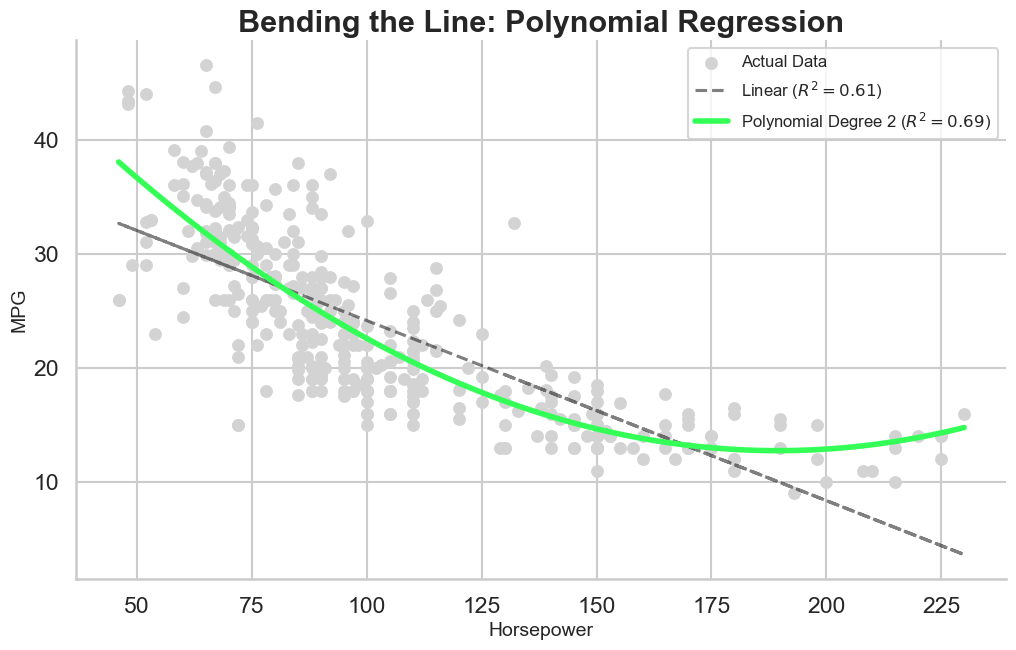

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Create a Pipeline (Transform -> Regress)
# This ensures raw data is transformed before prediction
poly_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

poly_pipeline.fit(X_raw, y_raw)

# 2. Generate smooth curve for plotting
X_grid = np.linspace(X_raw.min(), X_raw.max(), 100).reshape(-1, 1)
y_grid_pred = poly_pipeline.predict(X_grid)

# 3. Metrics
r2_poly = r2_score(y_raw, poly_pipeline.predict(X_raw))

# 4. Visualization
plt.figure(figsize=(12, 7))
plt.scatter(X_raw, y_raw, color='lightgray', s=60, label='Actual Data')

# Plot Linear vs Poly
plt.plot(X_raw, y_pred_sk, color='black', linestyle='--', alpha=0.5, label=f'Linear ($R^2={r2_score(y_raw, y_pred_sk):.2f}$)')
plt.plot(X_grid, y_grid_pred, color='#33FF57', linewidth=4, label=f'Polynomial Degree 2 ($R^2={r2_poly:.2f}$)')

plt.title("Bending the Line: Polynomial Regression", fontsize=22, weight='bold')
plt.xlabel("Horsepower", fontsize=14)
plt.ylabel("MPG", fontsize=14)
plt.legend(fontsize=12)
sns.despine()
plt.show()

### 3.4 Critique: Did it help?
Yes, significantly.

1.  **Accuracy Jump:** $R^2$ increased from **0.61** to **0.69**. We are explaining almost 10% more variance just by adding a squared term.
2.  **Physical Reality:** The green curve naturally follows the "diminishing returns" logic. A highly powerful car is inefficient, but efficiency levels off rather than going negative.

**The Interpretation Change:**
-   We now have two effects: a linear drop ($\beta_1$) and a quadratic curvature ($\beta_2$).
-   This allows the model to say: *"Efficiency drops fast when you add power to a weak engine, but the drop slows down for already powerful engines."*

However, we are still assuming the **Noise** is Normal (Gaussian). What if our data isn't a continuous number, but a count? Or a binary Yes/No? That is where **GLMs** come in.

## 4. Generalized Linear Models (GLMs): Beyond Normality

### 4.1 The Intuition
Ordinary regression makes a very strong assumption: **The errors are Normally distributed.**

But what if our target variable $y$ is:
-   **A Count:** Number of people at a table. (Integers: 1, 2, 3... cannot be 1.5).
-   **Strictly Positive:** Prices or time. (Cannot be negative).
-   **A Probability:** Yes/No chance. (Bounded between 0 and 1).

Fitting a straight line to this data is physically wrong. It could predict -2 people or 150% probability. **GLMs** solve this by introducing a **Link Function**.

$$ g(\mathbb{E}[y]) = \beta X $$

Instead of predicting $y$ directly, we predict a *function* of the average $y$. For count data, we use the **Poisson** distribution with a Log link, ensuring predictions are always positive.

### 4.2 The Dataset: Tipping (Party Size)
We will use the real-world **"Tips"** library dataset.
-   **Input ($X$):** Total Bill ($).
-   **Output ($y$):** Size (Number of people in the party).

Logic: Higher bills usually mean more people. But "People" is a count variable. You can't have 2.5 people. Let's see how OLS fails here.

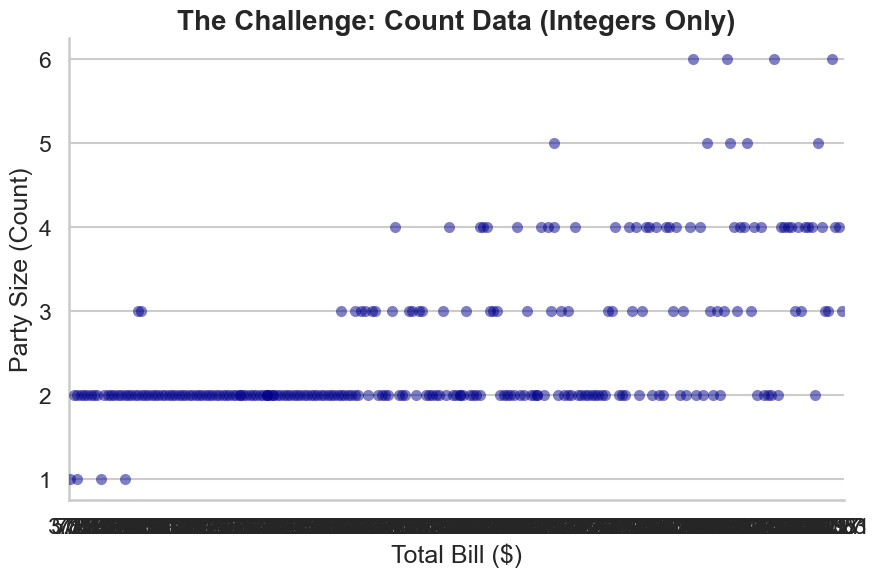

In [6]:
# 1. Load Data
df_tips = sns.load_dataset("tips")
X_tips = df_tips['total_bill'].values
y_tips = df_tips['size'].values

# Plot the raw data (Jitter added manually to see discrete levels)
plt.figure(figsize=(10, 6))
sns.stripplot(x=X_tips, y=y_tips, color='darkblue', alpha=0.5, s=8, jitter=True)
plt.title("The Challenge: Count Data (Integers Only)", fontsize=20, weight='bold')
plt.xlabel("Total Bill ($)")
plt.ylabel("Party Size (Count)")
plt.yticks([1, 2, 3, 4, 5, 6]) # Force integer ticks
sns.despine()
plt.show()

### 4.3 The Logic (From Scratch: Newton-Raphson)
Unlike OLS, there is no "closed-form" solution for GLMs. We must find the $\beta$ iteratively using **Maximum Likelihood Estimation (MLE)**.

We use the **Newton-Raphson** method (a.k.a. Iteratively Reweighted Least Squares). We start with a wild guess for $\beta$, calculate the gradient (slope of the error), and take a step downhill until we converge.

In [7]:
class ScratchPoissonGLM:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iters):
            # 1. Linear Model (log(mu) = wx + b)
            linear_model = np.dot(X, self.weights) + self.bias
            
            # 2. Link Function (Inverse Log = Exp)
            # y_pred is lambda (the rate/mean)
            y_pred = np.exp(linear_model)

            # 3. Compute Gradient (Derivative of Poisson Log-Likelihood)
            # dL/dw = X * (y_pred - y)
            # Note: This looks identical to OLS gradient but y_pred is exponential!
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 4. Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return np.exp(linear_model)

# Scale data to prevent overflow in exp()
X_tips_scaled = (X_tips - X_tips.mean()) / X_tips.std()

# Train Scratch Model (Reserving 2D structure for matrix math)
model_scratch_glm = ScratchPoissonGLM(learning_rate=0.1, n_iters=1000)
model_scratch_glm.fit(X_tips_scaled.reshape(-1, 1), y_tips)

print("Scratch GLM Parameters:")
print(f"Bias: {model_scratch_glm.bias:.4f}")
print(f"Weight: {model_scratch_glm.weights[0]:.4f}")

Scratch GLM Parameters:
Bias: 0.9227
Weight: 0.1976


### 4.4 The Professional Standard (Statsmodels is King here)
For GLMs, scientists often prefer `statsmodels` over `scikit-learn` because it provides detailed statistical summaries (p-values, standard errors).

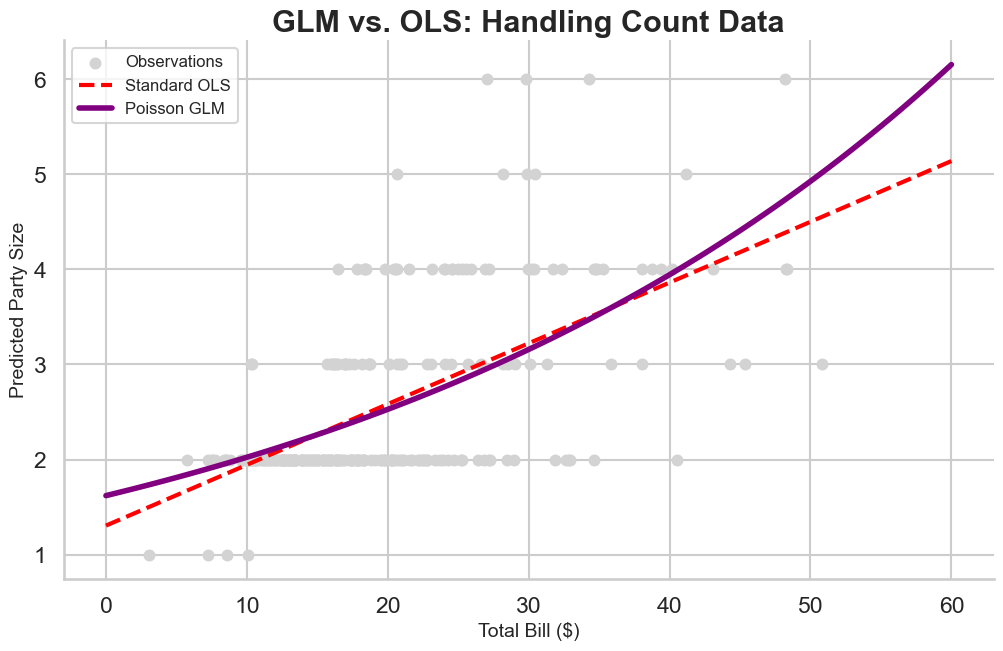

In [8]:
import statsmodels.api as sm

# 1. Prepare Data for Statsmodels (Add constant manually)
X_glm = sm.add_constant(X_tips)

# 2. Fit Poisson GLM
# Family=Poisson, Link=Log (default)
# We model log(Size) = beta0 + beta1 * Bill
glm_poisson = sm.GLM(y_tips, X_glm, family=sm.families.Poisson()).fit()

# 3. Fit Standard OLS for Comparison
ols_bad = sm.OLS(y_tips, X_glm).fit()

# 4. Visualization Comparison
x_range = np.linspace(0, 60, 100)
x_range_const = sm.add_constant(x_range)

# Predictions
y_pred_poisson = glm_poisson.predict(x_range_const)
y_pred_ols = ols_bad.predict(x_range_const)

plt.figure(figsize=(12, 7))
plt.scatter(X_tips, y_tips, color='lightgray', s=50, label='Observations')

plt.plot(x_range, y_pred_ols, color='red', linestyle='--', linewidth=3, label='Standard OLS')
plt.plot(x_range, y_pred_poisson, color='purple', linewidth=4, label='Poisson GLM')

plt.title("GLM vs. OLS: Handling Count Data", fontsize=22, weight='bold')
plt.xlabel("Total Bill ($)", fontsize=14)
plt.ylabel("Predicted Party Size", fontsize=14)
plt.legend(fontsize=12)
sns.despine()
plt.show()

### 4.5 Critique: Why is OLS "Wrong"?

Look at the red line (OLS) at the far left (Low Bill).
1.  **Intercept Issue:** The OLS line hits a size of ~1.4 at $0 bill. A linear line might eventually predict negative people if the bill could go negative (which it can't, but the model doesn't know that).
2.  **The Shape:** The Poisson curve (Purple) is subtle, but it is **curved**. It understands that as the bill gets very high, the number of people might grow exponentially (or at least non-linearly), whereas OLS is stuck on a straight path.
3.  **Variance:** Though harder to see here, OLS assumes the spread of "Party Size" is the same for a $5 bill and a $50 bill. In reality, a $50 bill has huge variance (could be 1 hungry person or 5 frugal ones), while a $5 bill is almost certainly 1 person. Poisson handles this variance structure naturally.

## 5. Partial Least Squares (PLS): The Curse of Dimensionality

### 5.1 The Intuition
**The Problem:** Standard regression fails when you have:
1.  **Multicollinearity:** Variables that are clones of each other.
2.  **p > n:** More variables (features) than samples (rows).

If you have 100 features and only 50 samples, OLS is mathematically impossible (infinite solutions). 

**The Solution:** We need to reduce the dimensions. 
-   **PCA (Principal Component Analysis):** Finds new axes that maximize *Variance of X* (ignoring $y$).
-   **PLS (Partial Least Squares):** Finds new axes that maximize *Covariance between X and y*. 

PLS is "Supervised" dimensionality reduction. It only keeps the information in X that actually helps predict y.

### 5.2 The Dataset: Wine Quality
We will use the **Wine Quality** dataset. It has many chemical features which are naturally correlated.

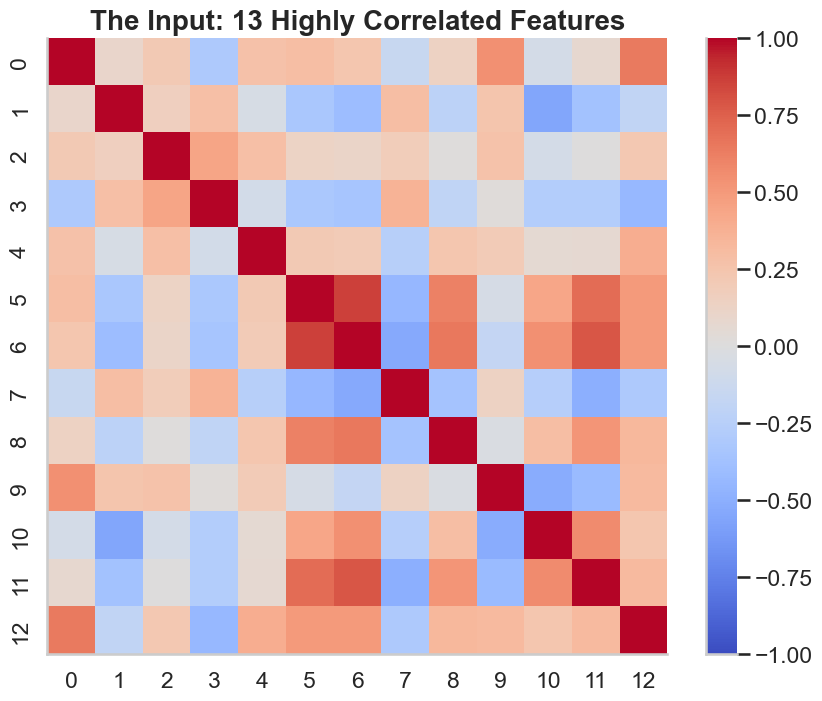

In [9]:
from sklearn.datasets import load_wine
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Data
data = load_wine()
X_wine = data.data
y_wine = data.target # 0, 1, 2 (Class)

# Standardize (Crucial for PLS/PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

# 2. Visualize the Multicollinearity
plt.figure(figsize=(10, 8))
# Set vmin/vmax to show full correlation range from -1 to 1
sns.heatmap(pd.DataFrame(X_scaled).corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title(f"The Input: {X_scaled.shape[1]} Highly Correlated Features", fontsize=20, weight='bold')
sns.despine()
plt.show()

### 5.3 The Logic (From Scratch: NIPALS)
How does PLS find these magic components? It uses an algorithm called **NIPALS** (Non-linear Iterative Partial Least Squares).

1.  Compute the covariance between $X$ and $y$ ($w = X^T y$).
2.  Project $X$ onto this weight vector to get a score $t$.
3.  Deflate $X$ and $y$ (remove the information we just found) and repeat.

In [10]:
class ScratchPLS:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.x_loadings_ = []
        self.x_weights_ = []

    def fit(self, X, y):
        # Center data (Crucial for PLS)
        self.X_mean = np.mean(X, axis=0)
        self.y_mean = np.mean(y)
        X_k = X - self.X_mean
        y_k = y - self.y_mean

        for _ in range(self.n_components):
            # 1. Calculate weights w = X^T * y
            # This finds direction of Max Covariance
            w = np.dot(X_k.T, y_k)
            w /= np.linalg.norm(w) # Normalize
            self.x_weights_.append(w)

            # 2. Calculate scores t = X * w
            t = np.dot(X_k, w)

            # 3. Calculate loadings p = X^T * t / t^T * t
            # How much of X is explained by t?
            div = np.dot(t.T, t)
            if div == 0: div = 1e-10
            p = np.dot(X_k.T, t) / div
            self.x_loadings_.append(p)

            # 4. Deflate X (Remove info explained by this component)
            # X_new = X_old - t * p^T
            # We remove the part of X that projects onto 't'
            X_k -= np.outer(t, p)

    def transform(self, X):
        # To transform new data, we must mimic the deflation process
        X_k = X - self.X_mean
        scores = []
        for w, p in zip(self.x_weights_, self.x_loadings_):
            # Project onto weight
            t = np.dot(X_k, w)
            scores.append(t)
            
            # Deflate X using the loading p
            # (Subtracting the component we just found from the data)
            X_k -= np.outer(t, p)
            
        return np.column_stack(scores)

# Execution using Wine Data
pls_scratch = ScratchPLS(n_components=2)
pls_scratch.fit(X_scaled, y_wine)
X_pls_scratch = pls_scratch.transform(X_scaled)

### 5.4 The Result: The Latent Space

We have projected the 13-dimensional chemical data into just 2 dimensions. Unlike PCA, which just looks for variance, PLS specifically looks for directions that separate the target classes (Wine Quality/Type).

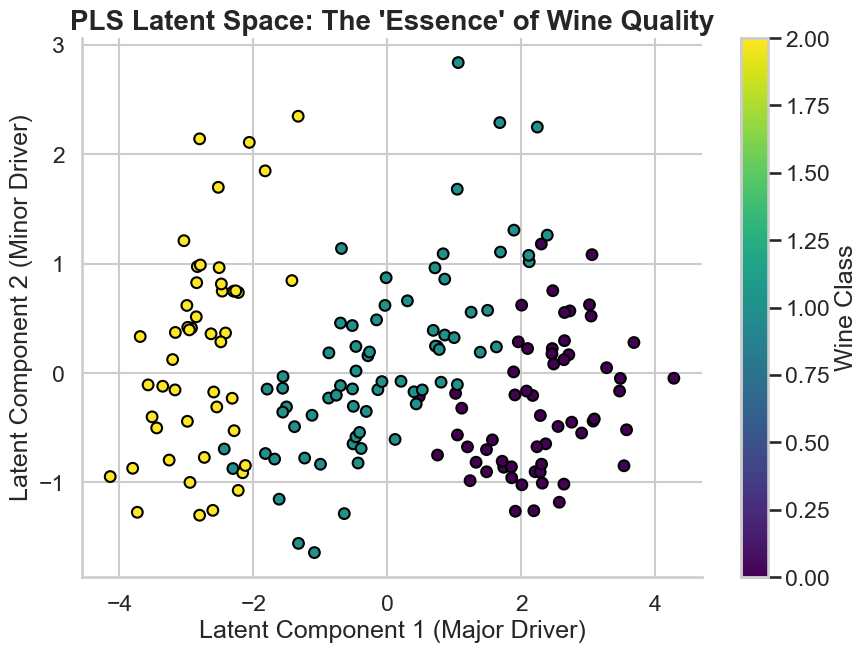

In [11]:
from sklearn.cross_decomposition import PLSRegression

# 1. Run PLS (Projecting 13 dimensions down to 2)
pls = PLSRegression(n_components=2)
X_pls = pls.fit_transform(X_scaled, y_wine)[0]

# 2. Plot the Latent Space
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pls[:, 0], X_pls[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
plt.title(f"PLS Latent Space: The 'Essence' of Wine Quality", fontsize=20, weight='bold')
plt.xlabel("Latent Component 1 (Major Driver)")
plt.ylabel("Latent Component 2 (Minor Driver)")
plt.colorbar(scatter, label='Wine Class')
sns.despine()
plt.show()

### 5.5 Critique: The Latent Space Revealed

The plot above reveals a fascinating truth about this dataset. We fed the model 13 complex chemical features, but PLS discovered that the "Wine Class" (0, 1, 2) is largely driven by a **single dominant chemical continuum**.

1.  **Component 1 (X-axis - The Super Feature):** This axis does 95% of the work. Notice the perfect ordinal arrangement: **Yellow (Type 2)** on the left, **Teal (Type 1)** in the middle, and **Purple (Type 0)** on the right. PLS successfully collapsed 13 dimensions into 1 single meaningful line that predicts the class.
2.  **Component 2 (Y-axis - The Variance):** Unlike the X-axis, this does **not** separate the classes significantly. Instead, it captures the "texture" or internal variation within the classes. Two purple wines might have the same Class likelyhood (same X) but very different secondary chemical profiles (different Y).

**Conclusion:** We don't need 13 variables to classify these wines. We really only need 1 specific linear combination of them. PLS found that needle in the haystack.